# Cinema Attendance and Ticket Prices in Germany: An Exploratory Data Analysis

**Author:** Federico Bonato  
**Date:** April 2025


## Introduction

This project explores cinema attendance patterns and ticket pricing across different federal states of Germany over time.  
The analysis aims to answer key questions regarding how cinema habits and infrastructure vary geographically and temporally,
and whether economic factors like ticket prices are correlated with audience behavior.

---

## Research Questions

1. **Evolution of Ticket Prices:**  
   How has the average cinema ticket price evolved over the years across different German states?

2. **Cinema Attendance Patterns:**  
   Which federal states have seen the highest and lowest number of cinema visits per inhabitant over time?

3. **Population vs. Attendance:**  
   How is the number of residents in a region related to the number of cinema visitors?

4. **Infrastructure vs. Attendance:**  
   How does the number of cinemas and screens in a region relate to the number of cinema visitors?

5. **Ticket Price vs. Attendance:**  
   Is there a relationship between average ticket prices and the number of cinema visits per inhabitant in each state?

---

## Suitable Analysis Methods

To investigate these questions, the following visual and statistical methods will be applied:

- **Line Plot:**  
  To visualize the development of average ticket prices over time per state.

- **Bar Plot / Heatmap:**  
  To compare cinema visits per inhabitant across states and years.

- **Scatter Plot:**  
  To explore relationships between average ticket prices, cinema visits, number of cinemas/screens, and population.

---

## Let's proceed with the code:

## 1. Import relevant libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from plot_polynomial_trends import plot_polynomial_trends

## 2. Data Loading and Initial Inspection

The data is loaded from '../data/21611-0003_en.csv'.

 **Data source:**  
This dataset was retrieved from the official portal of the German Federal Statistical Office:  
[GENESIS-Online, Destatis](https://www-genesis.destatis.de/datenbank/online/)



In [2]:
# Load the dataset
df = pd.read_csv('../data/21611-0003_en.csv', delimiter=';')

# Display basic information about the dataset
print("Dataset Overview:")
print("-----------------")
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

# Print list of regions
regions = df['Regions']
print("Regions included:\n", sorted(regions.unique()))

# Print range of years
years = df['Years']
print("\nYears covered:\n", sorted(years.unique()))


Dataset Overview:
-----------------

Dataset shape: (404, 9)

Columns: ['Regions', 'Years', 'Cinemas', 'Screens', 'Cinema seats', 'Cinema visits', 'Cinema visits per inhabitant', 'Average cinema ticket price', 'Gross receipts from cinema visits']

First few rows:


,Regions,Years,Cinemas,Screens,Cinema seats,Cinema visits,Cinema visits per inhabitant,Average cinema ticket price,Gross receipts from cinema visits
0,Baden-Württemberg,2000.0,258.0,626.0,110626.0,18.5,1.8,5.57,103.2
1,Baden-Württemberg,2001.0,249.0,621.0,110251.0,22.4,2.1,5.67,127.2
2,Baden-Württemberg,2002.0,252.0,629.0,109265.0,21.3,2.0,5.89,125.3
3,Baden-Württemberg,2003.0,262.0,656.0,111429.0,19.3,1.8,5.79,112.1
4,Baden-Württemberg,2004.0,260.0,656.0,112175.0,20.8,1.9,5.81,120.6


Regions included:
 ['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Source:\nGerman Federal Film Board, Berlin\n\nCinema seats:\n2000-2011: Seats excluding open-air, university cinemas and \nclosures. \nFrom 2012: Seats excluding open-air, university cinemas, \nfilm festivals and closures.\n\nAverage cinema ticket price:\nGross prices.\n\n2019: \nDue to a changed allocation in the area of traveling\ncinemas, there is a disproportionate increase in the \nfigures for cinemas, screens and cinema seats.', 'Thüringen', '__________', 'created: 2025-04-21 / 10:52:10', '© Statistisches Bundesamt (Destatis), 2025']

Years covered:
 [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022

The dataset consists of **yearly cinema-related statistics** across the 16 German federal states from **2000 to 2024**. Each row represents a combination of a state and a year.

**Regions included:**
- Baden-Württemberg
- Bayern
- Berlin
- Brandenburg
- Bremen
- Hamburg
- Hessen
- Mecklenburg-Vorpommern
- Niedersachsen
- Nordrhein-Westfalen
- Rheinland-Pfalz
- Saarland
- Sachsen
- Sachsen-Anhalt
- Schleswig-Holstein
- Thüringen

**Years covered:**
- 2000 to 2024 (25 years)

**Indicators available:**
- Total cinemas
- Total screens
- Total seats
- Total visits
- Visits per capita
- Average ticket price (EUR)
- Total revenue (EUR)

## 3. Data Cleaning:

After the step 2 i have realized that at least exist a `NaN` value.
For this reason, before starting my analysis, I would proceed with a few essential data cleaning steps to ensure consistency and readability:

- The `Year` column was initially stored as float values (e.g., `2000.0`). Since years are discrete entities, I converted them to integers.
- I noticed that one row had a missing value (`NaN`) in the `Year` column. Since each entry in the dataset should correspond to a valid year and region, I exclude this row.
- To avoid inconsistencies during the analysis, I also look for any remaining rows that contained missing values in any other column and keep it out.

These operations help ensure that the dataset is clean, well-structured, and ready for further exploration.

In [3]:
#1. Check for NaN values in the dataframe:

print("NaN values per column:")
nan_values = df.isna().sum()
print(nan_values)

# Drop NaN values and create clean dataframe
df_clean = df.dropna()

print("------- After cleaning -------")
print(f"Total rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

# Update the original dataframe
df = df_clean

#2. # Convert Years column to integer type
df['Years'] = df['Years'].astype(int)
years = df['Years']
print("Years data type after conversion:", df['Years'].dtype)


NaN values per column:
Regions                              0
Years                                4
Cinemas                              4
Screens                              4
Cinema seats                         4
Cinema visits                        4
Cinema visits per inhabitant         4
Average cinema ticket price          4
Gross receipts from cinema visits    4
dtype: int64
------- After cleaning -------
Total rows: 400
Rows removed: 4
Years data type after conversion: int64


Now everytime i refer to `df`, it will be the cleaned version. 
As expected the number of removed rows is the same of the NaN values.
This guarantees that the data is clean and ready for analysis.

### 3.1 Creating Data Structures for Analysis

Before diving into our analysis questions, let's create some useful data structures that will help us maintain consistency throughout our exploration:

- **Regional Data Dictionary**: A dictionary containing separate dataframes for each federal state, allowing easy access to region-specific data


These structures will help us:
- Maintain consistent analysis across all research questions
- Ensure visual consistency in our plots
- Make our code more efficient and readable
- Reduce redundancy in our analysis

In [4]:
# Create dictionary of regional dataframes
regional_data = {
    region: df[df['Regions'] == region].copy().sort_values('Years') 
    for region in sorted(df['Regions'].unique())
}


## 4. Data Analysis and Visualization

### Question number 1: Evolution of Ticket Prices

Let's analyze how average cinema ticket prices have changed over time across different German states:
- Plot the trend of average ticket prices for all states
- Identify states with highest and lowest price increases
- Calculate the overall price change percentage from 2000 to 2024

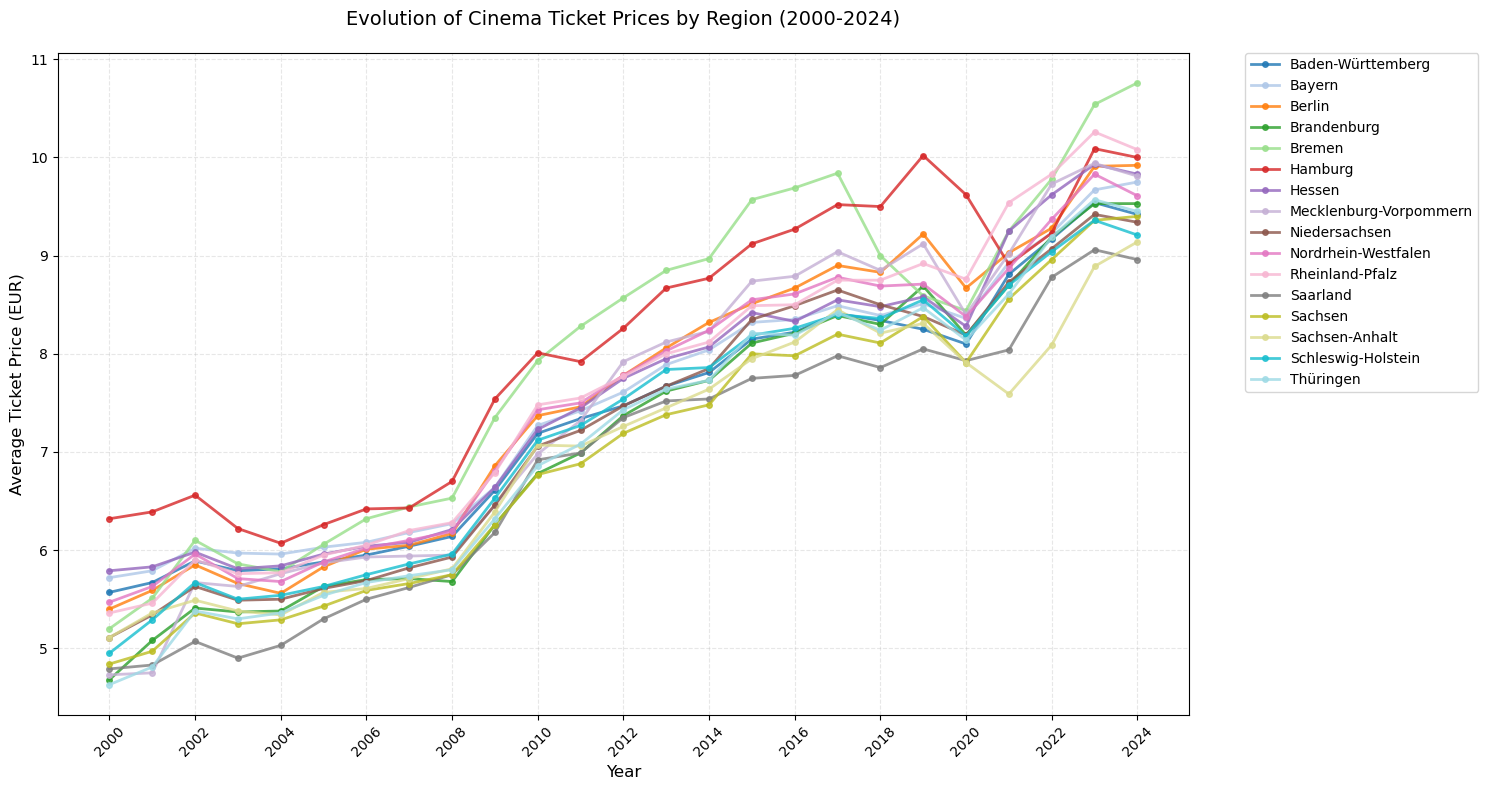

In [5]:
################################################################################
# 4.1: Plot the trend of average ticket prices for all states

# Set up the figure size
plt.figure(figsize=(15, 8))

# Create color map for regions
colors = plt.cm.tab20(np.linspace(0, 1, len(regional_data)))
region_colors = dict(
    zip(sorted(regional_data.keys()), colors)
)

# Plot each region's price evolution
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Average cinema ticket price'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=region,
        color=region_colors[region],
        alpha=0.8
    )

# Customize the plot
plt.title(
    'Evolution of Cinema Ticket Prices by Region (2000-2024)',
    fontsize=14,
    pad=20
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Ticket Price (EUR)', fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.3)

# Customize legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=10
)

# Customize x-axis
plt.xticks(
    sorted(df['Years'].unique())[::2],
    rotation=45
)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

## 4.1: Let's check and plot which is the plynomial that represent better the trend of this evolution:

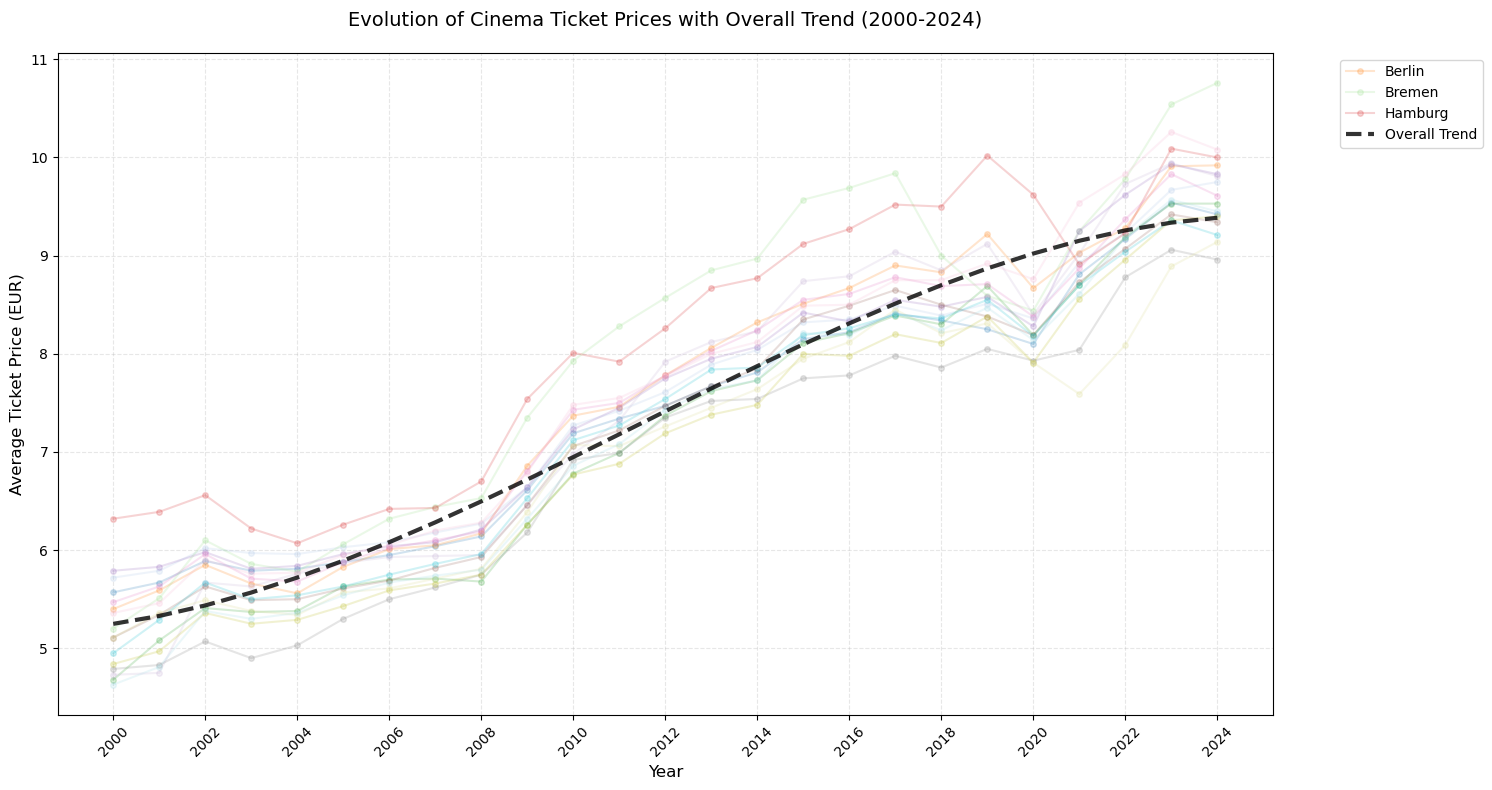

In [6]:
# Plot ticket prices evolution with polynomial trend
plt.figure(figsize=(15, 8))

# Plot individual lines with low opacity
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Average cinema ticket price'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=region_colors[region],
        alpha=0.2,
        label=region if region in ['Berlin', 'Hamburg', 'Bremen'] else ""
    )

# Add polynomial trend
plot_polynomial_trends(
    data_groups=[df],
    column_name='Average cinema ticket price',
    years=sorted(df['Years'].unique()),
    colors=['black'],
    labels=['Overall Trend'],
    title='Evolution of Cinema Ticket Prices with Overall Trend (2000-2024)'
)

# Customize plot
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Ticket Price (EUR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sorted(df['Years'].unique())[::2], rotation=45)
plt.tight_layout()
plt.show()

### Analysis of the Polynomial Trend

**Key Findings**:
   - The trend shows a clear non-linear increase in ticket prices over time
   - The rate of price increase has not been constant
   - There's evidence of price growth moderation in recent years
   - The model suggests a possible plateau effect in future prices

This polynomial fit helps us understand that cinema ticket prices haven't simply increased linearly, but have followed a more complex pattern of acceleration and deceleration over the studied period (a notable disruption occurred in 2020 (COVID-19 pandemic), followed by  a steeper price increase across all regions)

### 4.2 Analyzing Price Changes (2000-2024)

Let's identify:
1. States with the highest and lowest price increases
2. Overall price change across all regions

In [7]:
################################################################################
# 4.2: Calculate price changes for each region
price_changes = {}
for region, data in regional_data.items():
    initial_price = data.iloc[0]['Average cinema ticket price']
    final_price = data.iloc[-1]['Average cinema ticket price']
    pct_change = ((final_price - initial_price) / initial_price) * 100
    price_changes[region] = pct_change

# Convert to Series:
changes = pd.Series(price_changes).round(2)

# Get Hamburg's data from the regional_data dictionary:
hamburg_data = regional_data['Hamburg']
hamburg_min = hamburg_data['Average cinema ticket price'].min()
hamburg_max = hamburg_data['Average cinema ticket price'].max()

# Get Mecklenburg-Vorpommern's data from the regional_data dictionary:
mecklenburg_data = regional_data['Mecklenburg-Vorpommern']
mecklenburg_min = mecklenburg_data['Average cinema ticket price'].min()
mecklenburg_max = mecklenburg_data['Average cinema ticket price'].max()

print(f"Minimum increase: +{changes.min()}% ({changes.idxmin()})")
print(f'From: {hamburg_min} -> to {hamburg_max}')
print(f"Maximum increase: +{changes.max()}% ({changes.idxmax()})")
print(f'From: {mecklenburg_min} -> to {mecklenburg_max}')
# Plot the price changes




Minimum increase: +58.23% (Hamburg)
From: 6.07 -> to 10.09
Maximum increase: +107.4% (Mecklenburg-Vorpommern)
From: 4.73 -> to 9.94


## Question 2: Cinema Attendance Patterns

### 5.1 Evolution of Cinema Visits per Capita

Let's analyze how cinema attendance has changed over time across different German states by:
1. Plotting attendance trends for all states
2. Identifying regions with highest and lowest attendance
3. Examining the impact of significant events (e.g., COVID-19 pandemic)

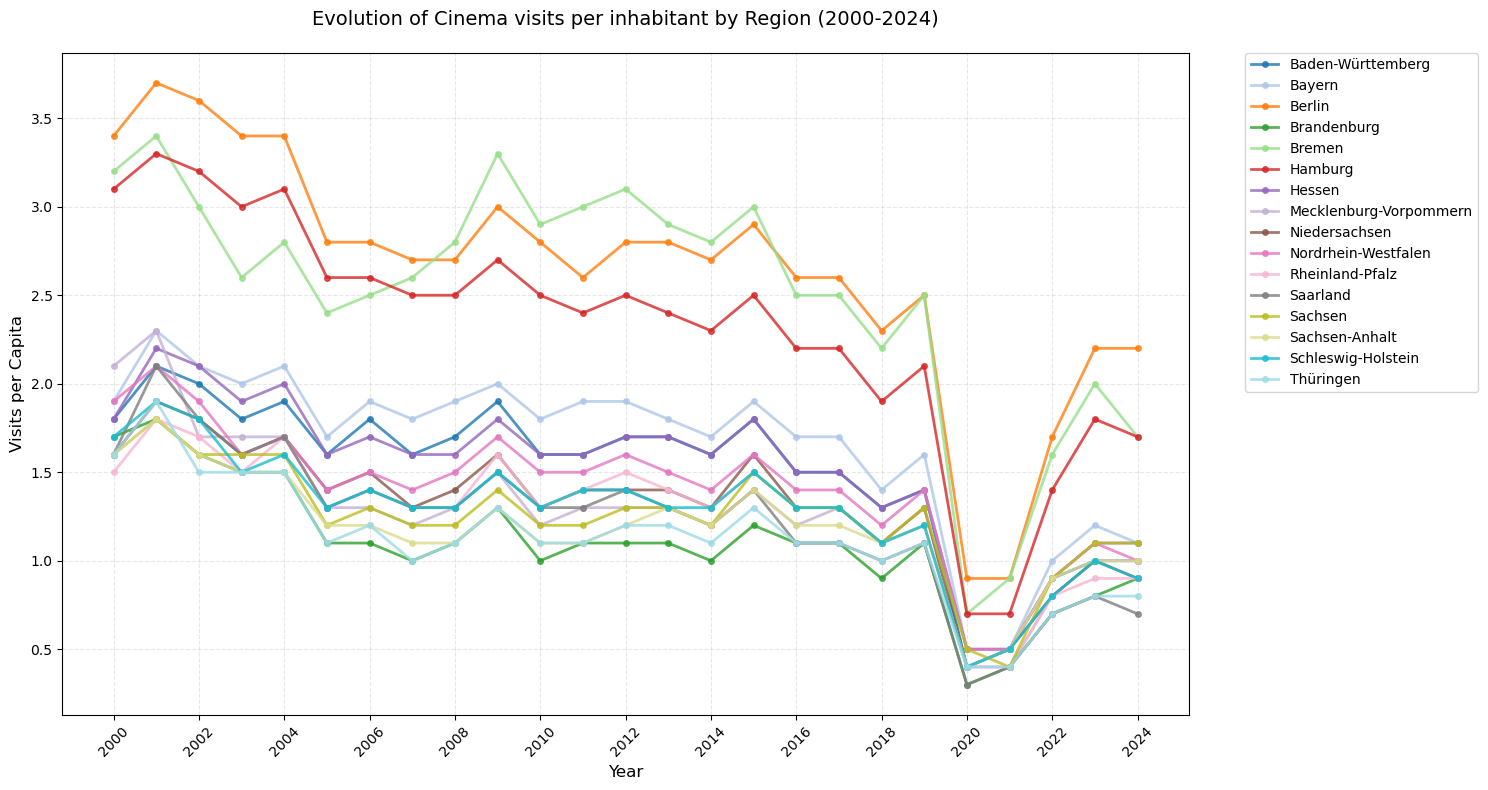

In [8]:
################################################################################
# 5.1: Plot the trend of cinema visits per capita for all states
''' Using the same color map (region_colors) and regional data dictionary
 created in section 4.1 for consistency across visualizations'''

# Set up the figure size
plt.figure(figsize=(15, 8))

# Plot each region's attendance evolution (using existing color map)
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Cinema visits per inhabitant'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=region,
        color=region_colors[region],
        alpha=0.8
    )

# Customize the plot
plt.title(
    'Evolution of Cinema visits per inhabitant by Region (2000-2024)',
    fontsize=14,
    pad=20
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Visits per Capita', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=10
)
plt.xticks(
    sorted(df['Years'].unique())[::2],
    rotation=45
)
plt.tight_layout()
plt.show()
